# Debugging Notebook for functions

In [1]:
%load_ext autoreload
%autoreload 2

In [43]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
import numpy as np
import matplotlib.pyplot as plt

(0.37317537434954356-0.9097549124773161j)
for layer 0
(1+0j)
for layer 1
(0.37317537434954356-0.9097549124773161j)
for layer 2
(1+0j)
for layer 3
[0.3532568  0.90276607 0.16886981 0.01681836 0.17726586 0.
 0.         0.        ]


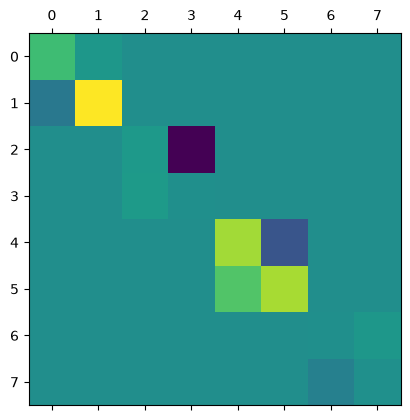

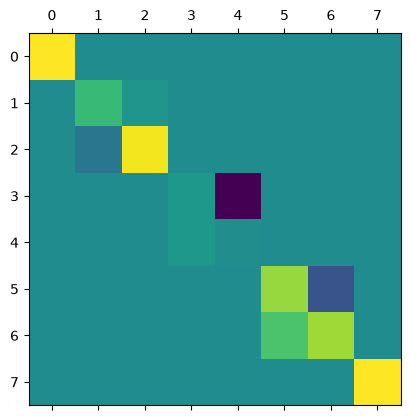

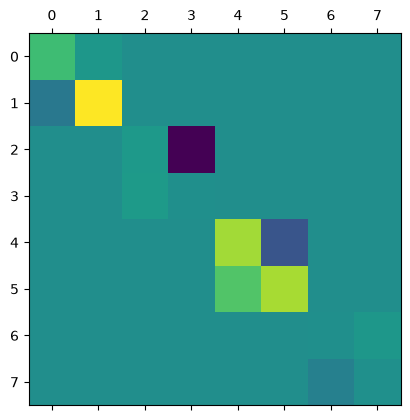

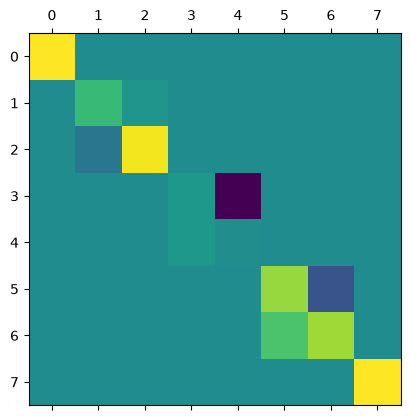

In [3]:
E_in = np.array([0,1,0,0,0,0,0,0])

rng = np.random.default_rng()

n = 4  # Beispiel-Länge

# 2. Werte zwischen 0 und 2*pi
thetas = rng.uniform(0, 2 * np.pi, n)

# 3. Werte zwischen 0 und pi
phis = rng.uniform(0, np.pi, n)

for l in range(n): #for each layer
    M=build_single_layer(thetas, phis, pos=l)
    plt.matshow(np.real(M))
    print(M[0,0])
    print("for layer "+str(l))
    E_out = forward_single_layer(E_in, M)
    E_in = E_out
print(np.abs(E_out))


In [4]:
import numpy as np
l,w = 2,3
rng = np.random.default_rng()
thetas = rng.uniform(0, 2 * np.pi, (w,l))
print(thetas)

[[0.32608556 5.0326278 ]
 [5.08506984 6.13896666]
 [4.40219156 0.78610841]]


[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 0. 1. 0. 1.]]


C:\Users\tim\AppData\Local\Temp\ipykernel_33552\2539130067.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


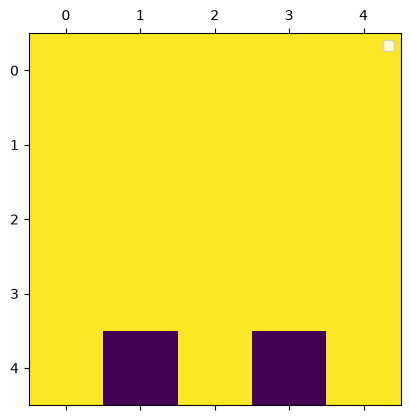

In [5]:
a=np.ones((5,5))
a[-1, 1::2] = 0

plt.matshow(a)
plt.legend()
print(a)

In [6]:
a=set_random_weights(3,3)


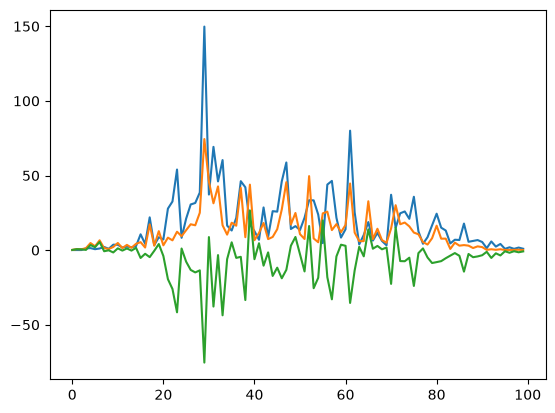

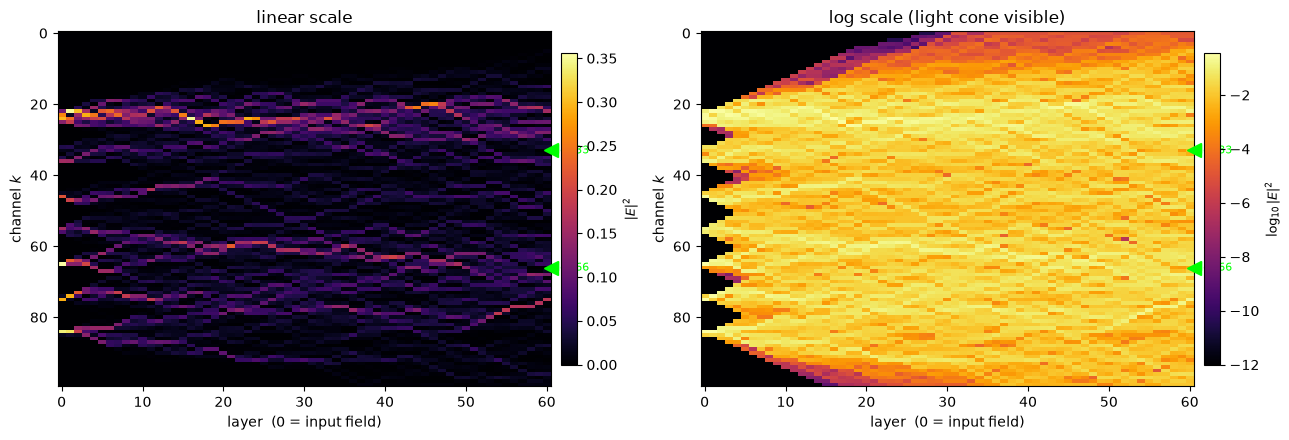

In [48]:
# --- Intensitaets-Plot, realistisches Mesh N=100 ---
N2, L2 = 100, 60
number=300
p2 = set_random_weights(L2, N2 // 2)
E, y = get_data(np.array([7]), mode="Test", number=number, m=10, theta=1, normalize_energy=False)
I_end_7=np.zeros((100))
for z in range(number):
    I=np.abs(forward_all_layers_with_history(E[z], p2))**2
    I_end_7+=I[-1,:]
plt.plot(I_end_7)

E, y = get_data(np.array([1]), mode="Test", number=number, m=10, theta=1, normalize_energy=False)
I_end_1=np.zeros((100))
for z in range(number):
    I=np.abs(forward_all_layers_with_history(E[z], p2))**2
    I_end_1+=I[-1,:]
plt.plot(I_end_1)

diffI_7_to_I_1 = I_end_1-I_end_7

plt.plot(diffI_7_to_I_1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_intensity_map(I2, detectors=[33, 66], ax=axes[0],#
                    title="linear scale")
plot_intensity_map(I2, detectors=[33, 66], ax=axes[1], log=True,
                    title="log scale (light cone visible)")
fig.tight_layout()

(13007, 28, 28)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  124 253 255  63   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  96
  244 251 253  62   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 127
  251 251 253  62   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   